### Visualization

In [1]:
from helper_functions import *
import os
from datetime import datetime
print(os.getcwd())
params = 'l1_3.00_Dc_1.00_Nsites_300.00'

files = [f for f in os.listdir('/scratch.local/gtucci/micro/julia/') if f.startswith(params)]

def extract_datetime(filename):
    # last two parts are date and time
    parts = filename.rsplit('_', 2)
    date_str = parts[-2]
    time_str = parts[-1]
    return datetime.strptime(f"{date_str}_{time_str}", "%Y-%m-%d_%H%M%S")

most_recent = max(files, key=extract_datetime)

path = os.path.join('/scratch.local/gtucci/micro/julia/' + most_recent)

occupancies_t, tau_t, _, _, _ = load_sim(path)

path

/home/beq/gtucci/Work/DiscreteChemo/DiscreteChemo/Microscopic


'/scratch.local/gtucci/micro/julia/l1_3.00_Dc_1.00_Nsites_300.00_2026-04-28_111309'

In [3]:
np.save('./occs_test_local.npy', occupancies_t)

In [2]:
occupancies_t.shape, tau_t.shape

((12, 3, 300), (12,))

To plot, there are 4 parameters to specify:
- w (here 12) is the mesoscopic box size taken for the averaging. 
- start (here 0) and
end (here 1) are the start and end point of the time window you want to see. So if you want to only see the second half of time values you would make these 0.5 and 1.
- Nlines (here 5) is the number of lines you want to see (each for a different time).

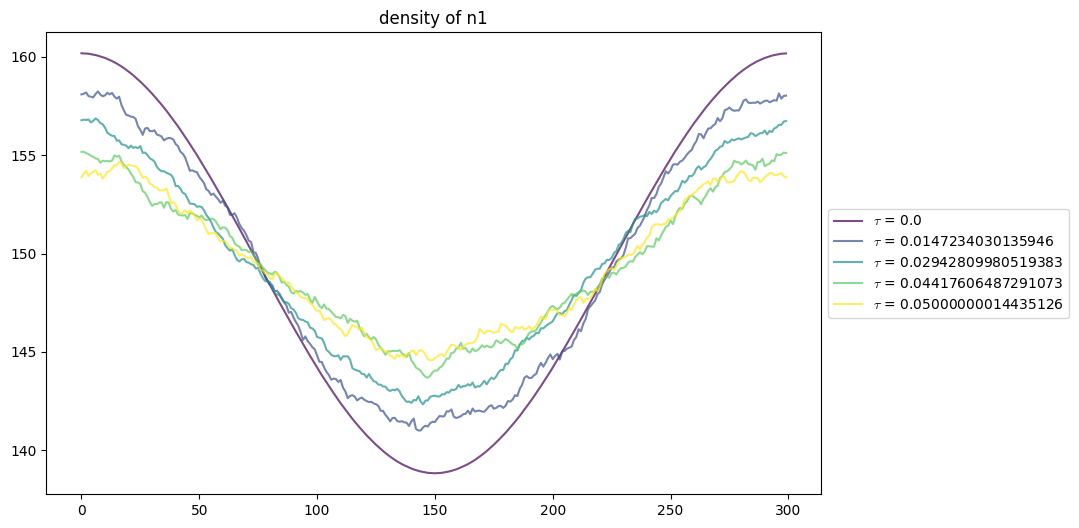

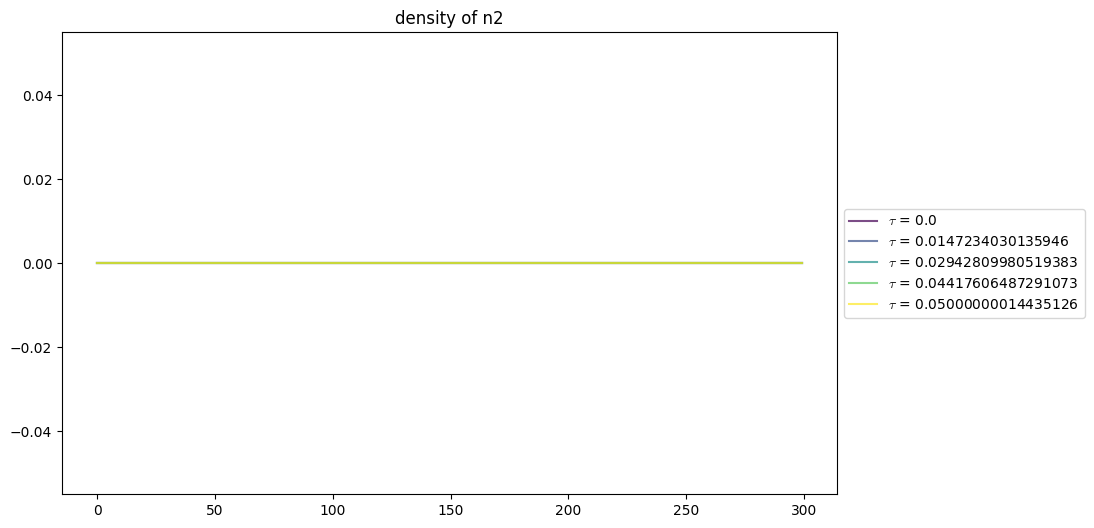

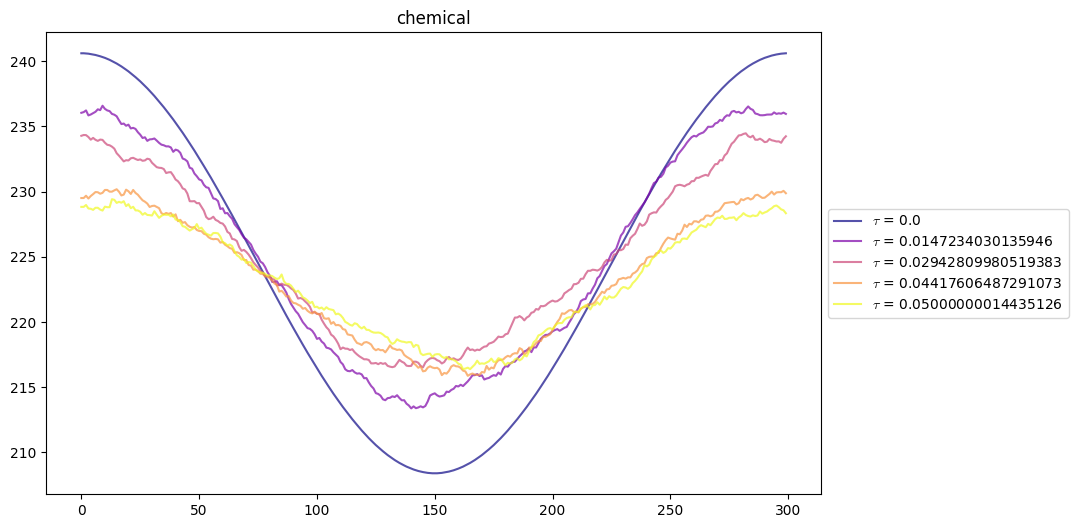

In [71]:
w = 65

plot_results(occupancies_t, tau_t, w, 0, 1, 5)

In [113]:
def periodic_derivative(array):
    N = len(array)
    dx = 1 / N
    output = np.zeros(N, dtype=float)

    for i in range(N):
        output[i] = (array[(i+1) % N] - array[(i-1) % N]) / (2 * dx)

    return output

def periodic_second_derivative_4th(array):
    dx = 1 / len(array)
    return (
        -np.roll(array, 2)
        + 16*np.roll(array, 1)
        - 30*array
        + 16*np.roll(array, -1)
        - np.roll(array, -2)
    ) / (12 * dx**2)

def spectral_filter(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(rho_hat_filtered))

def spectral_derivative_filtered(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(1j*(2*np.pi*k) * rho_hat_filtered))

def spectral_second_derivative_filtered(rho, cutoff=0.2):
    N = len(rho)
    k = np.fft.fftfreq(N, d=1/N)
    
    rho_hat = np.fft.fft(rho)
    
    # low-pass filter
    mask = np.abs(k) < cutoff * N
    rho_hat_filtered = rho_hat * mask
    
    return np.real(np.fft.ifft(-(2*np.pi*k)**2 * rho_hat_filtered))
# plt.plot(periodic_derivative(meso_avg(occupancies_t[0, 2, :], w)))

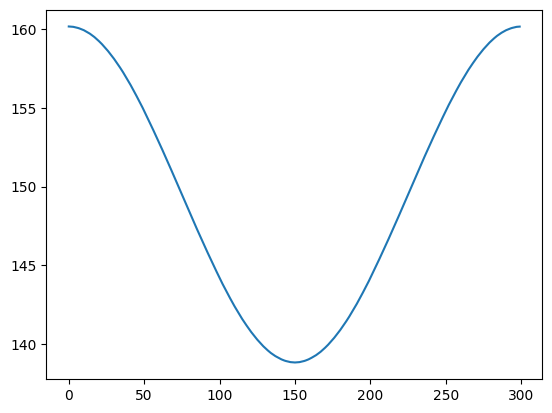

In [72]:
plt.plot(meso_avg(occupancies_t[i, 0, :], w))

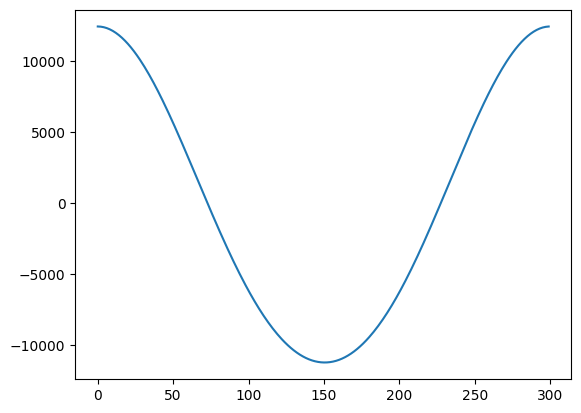

In [119]:
lambd = 3
D = 1

i = 0
w = 15
rho = meso_avg(occupancies_t[i, 0, :], w)
gamma = meso_avg(occupancies_t[i, 2, :], w)

c = 2 / 300
rho_f = spectral_filter(rho, cutoff=c)
gamma_f = spectral_filter(gamma, cutoff=c)
rhox = spectral_derivative_filtered(rho, cutoff=c)
gammax=spectral_derivative_filtered(gamma, cutoff=c)
rhoxx = spectral_second_derivative_filtered(rho, cutoff=c)
gammaxx = spectral_second_derivative_filtered(gamma, cutoff=c)

partialt_rho_dt = 0.05 * (D + 0.5 * lambd) * rhoxx - lambd / np.sqrt(np.pi) * (rho_f * gammaxx / np.sqrt(gamma_f) + rhox * gammax / np.sqrt(gamma_f) - 0.5 * rho_f * gammax ** 2 / np.sqrt(gamma_f ** 3))
#partialt_rho -= lambd * periodic_derivative(rho * periodic_derivative(gamma) * T1(gamma)/ gamma)
plt.plot(partialt_rho)

In [64]:
periodic_second_derivative_4th(rho)

array([-2.13162821e-10,  2.41935484e+02, -3.38709677e+03,  2.41935484e+02,
        6.39488462e-10,  8.52651283e-10,  1.06581410e-09,  1.27897692e-09,
        2.41935484e+02, -3.38709677e+03,  2.41935484e+02, -3.83693077e-09,
       -3.19744231e-09, -2.77111667e-09,  4.83870968e+02, -7.01612903e+03,
        3.87096774e+03, -2.41935484e+02, -2.77111667e-09,  2.41935484e+02,
       -3.38709677e+03,  2.41935484e+02, -2.55795385e-09, -5.11590770e-09,
        2.41935484e+02, -3.38709677e+03,  2.41935484e+02, -8.52651283e-10,
        2.41935484e+02, -3.38709677e+03,  2.41935484e+02, -2.34479103e-09,
       -1.06581410e-09,  3.83693077e-09, -5.11590770e-09,  2.41935484e+02,
       -3.38709677e+03,  2.41935484e+02,  1.06581410e-09, -4.26325641e-09,
        4.05009359e-09, -1.27897692e-09,  2.41935484e+02, -3.38709677e+03,
        2.41935484e+02, -2.41935484e+02,  3.62903226e+03, -3.62903226e+03,
        2.41935484e+02,  2.41935484e+02, -3.62903226e+03,  3.62903226e+03,
        4.68958206e-09, -

In [6]:
np.mean(occupancies_t[-1, 2,:]), np.var(occupancies_t[-1, 2,:])

(np.float64(223.21666666666667), np.float64(269.6097222222222))

In [7]:
np.mean(occupancies_t[-1, 0,:]), np.var(occupancies_t[-1, 0,:])

(np.float64(149.50666666666666), np.float64(176.80328888888891))

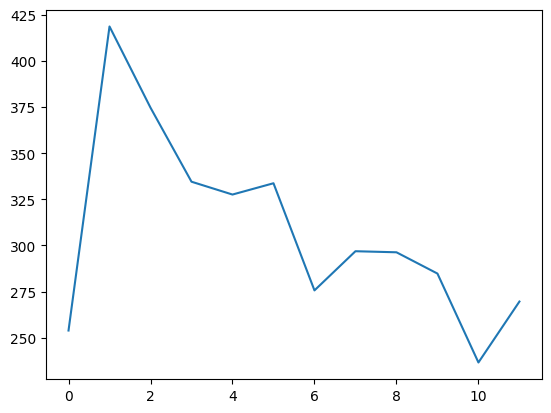

In [8]:
plt.plot([np.var(occupancies_t[i, 2,:]) for i in range(occupancies_t.shape[0])])

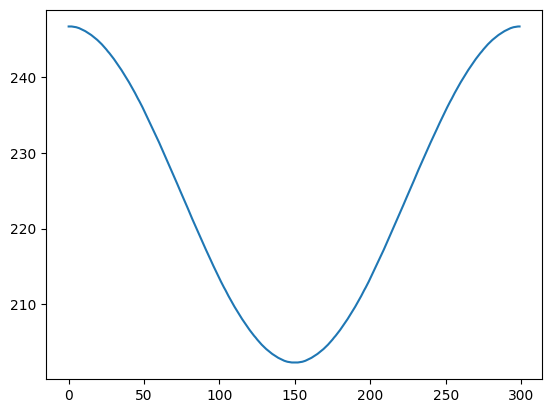

In [9]:
meso = np.zeros(occupancies_t.shape, dtype=float)

for i, _ in enumerate(occupancies_t):
    meso[i,2,:] = meso_avg(occupancies_t[i,2,:], w)

plt.plot(meso[0, 2,:])

In [10]:
meso.shape

(12, 3, 300)

In [11]:
import numpy as np

# choose 10 indices (example: random)
indices = np.random.choice(len(tau_t), size=49, replace=False)

c = np.mean(meso[0, 2, :])
a = meso[0, 2, 0] - c
print(c)

# get elements at those indices
meso = meso[indices]
tau_t = tau_t[indices]

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exponential(a, c):
    def f(x, b):
        return a * np.exp(b * x) + c
    return f

p_opt, p_cov = curve_fit(exponential(a, c), tau_t, meso[:,2, 0], p0=(-20))

x_fit = np.linspace(min(tau_t), max(tau_t), 100)
y_fit = exponential(a, c)(x_fit, *p_opt)

plt.figure(figsize=(8, 5))

plt.scatter(tau_t[:], meso[:,2, 0], color='gray', alpha=0.4, label='Data (Col 20)')

plt.plot(x_fit, y_fit, color='red', linewidth=2, 
         label=fr'Fit: $ae^{{b\tau}} + c$ with $(a, b, c)$ = {p_opt}')

# 3. Formatting
plt.xlabel(r'$\tau$')
plt.ylabel('Occupancy')
plt.title('Exponential Fit to Occupancy Data')

# Snap the frame to the data
plt.axis('tight') 

# Display the legend
plt.legend()

plt.show()

24. sth for kappa = 1
24.8 for kappa = 2
and 
33 or so for kappa = 10 (should be like 30) and 600 entries
let's see what it is for 400

In [ ]:
(5 / 3)**3

In [ ]:
# we should be getting a decay rate of Dc / 2 * (2pi / N)^2 - kappa, where Dc and kappa are the numbers in the simulation for 200 sites it's 1 * 200 * 2

0.1*(2 * np.pi) ** 2 + 1